<a href="https://colab.research.google.com/github/EkaMiharja/MalnutritionClassification_DecisionTree/blob/main/MalnutritionClassification_DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Library

In [1]:
import pandas as pd # Untuk analisis dan manipulasi data
import numpy as np # Untuk operasi numerik dan array

import matplotlib.pyplot as plt # Untuk visualisasi data
import seaborn as sns # Untuk visualisasi data statistik yang lebih menarik

from sklearn.preprocessing import LabelEncoder # Untuk mengkodekan label kategorikal ke numerik
from sklearn.model_selection import train_test_split # Untuk membagi dataset menjadi data latih dan uji

from sklearn.tree import DecisionTreeClassifier # Untuk membangun model pohon keputusan klasifikasi
from sklearn.tree import plot_tree # Untuk memvisualisasikan pohon keputusan

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # Untuk evaluasi performa model

## 2. Import Dataset

# a. Baca dataset dan tampilkan

In [57]:
df = pd.read_csv('/content/data_balita.csv')
df

,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),Status Gizi
0,0,laki-laki,44.591973,stunted
1,0,laki-laki,56.705203,tinggi
2,0,laki-laki,46.863358,normal
3,0,laki-laki,47.508026,normal
4,0,laki-laki,42.743494,severely stunted
...,...,...,...,...
120994,60,perempuan,100.600000,normal
120995,60,perempuan,98.300000,stunted
120996,60,perempuan,121.300000,normal
120997,60,perempuan,112.200000,normal


# b. Menampilkan 5 Data Pertama

In [7]:
df.head()

,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),Status Gizi
0,0,laki-laki,44.591973,stunted
1,0,laki-laki,56.705203,tinggi
2,0,laki-laki,46.863358,normal
3,0,laki-laki,47.508026,normal
4,0,laki-laki,42.743494,severely stunted


# c. Menampilkan 5 Data Terakhir

In [8]:
df.tail()

,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),Status Gizi
120994,60,perempuan,100.6,normal
120995,60,perempuan,98.3,stunted
120996,60,perempuan,121.3,normal
120997,60,perempuan,112.2,normal
120998,60,perempuan,109.8,normal


# d. Mengetahui Jumlah Baris dan Kolom

In [9]:
print(df.shape)

(120999, 4)


# e. Melihat Nama Kolom

In [10]:
print(df.columns)

Index(['Umur (bulan)', 'Jenis Kelamin', 'Tinggi Badan (cm)', 'Status Gizi'], dtype='object')


# f. Melihat Tipe Data Setiap Kolom

In [11]:
df.dtypes

,0
Umur (bulan),int64
Jenis Kelamin,object
Tinggi Badan (cm),float64
Status Gizi,object


# g. Melihat Informasi Lengkap Dataset

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120999 entries, 0 to 120998
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Umur (bulan)       120999 non-null  int64  
 1   Jenis Kelamin      120999 non-null  object 
 2   Tinggi Badan (cm)  120999 non-null  float64
 3   Status Gizi        120999 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 3.7+ MB


# h. Melihat Statistik Deskriptif Kolom Numerik

In [13]:
df.describe()

,Umur (bulan),Tinggi Badan (cm)
count,120999.000000,120999.000000
mean,30.173803,88.655434
std,17.575119,17.300997
min,0.000000,40.010437
25%,15.000000,77.000000
50%,30.000000,89.800000
75%,45.000000,101.200000
max,60.000000,128.000000


# i. Melihat Statistik Semua Kolom

In [14]:
df.describe(include='all')

,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),Status Gizi
count,120999.000000,120999,120999.000000,120999
unique,NaN,2,NaN,4
top,NaN,perempuan,NaN,normal
freq,NaN,61002,NaN,67755
mean,30.173803,NaN,88.655434,NaN
std,17.575119,NaN,17.300997,NaN
min,0.000000,NaN,40.010437,NaN
25%,15.000000,NaN,77.000000,NaN
50%,30.000000,NaN,89.800000,NaN
75%,45.000000,NaN,101.200000,NaN


## 3. Cleaning Data

# a. Cek Missing Value

In [15]:
df.isnull().sum()

,0
Umur (bulan),0
Jenis Kelamin,0
Tinggi Badan (cm),0
Status Gizi,0


# b. Cek Data Duplikat

In [17]:
df.duplicated().sum()

np.int64(81574)

# c. Hapus Data Duplikat

In [22]:
df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

# d. Cek Nilai Unik pada Jenis Kelamin

In [33]:
df['Jenis Kelamin'].unique()

array(['laki-laki', 'perempuan'], dtype=object)

# e. Cek Nilai Unik Status Gizi

In [32]:
df['Status Gizi'].unique()

array(['stunted', 'tinggi', 'normal', 'severely stunted'], dtype=object)

# f. Cek Jumlah Data Setelah Cleaning

In [30]:
print(df.shape)

(39425, 4)


## 4. Eksplorasi Data

# a. Menampilkan Distribusi Status Gizi

Status Gizi
normal              21514
tinggi               6974
severely stunted     6520
stunted              4417
Name: count, dtype: int64


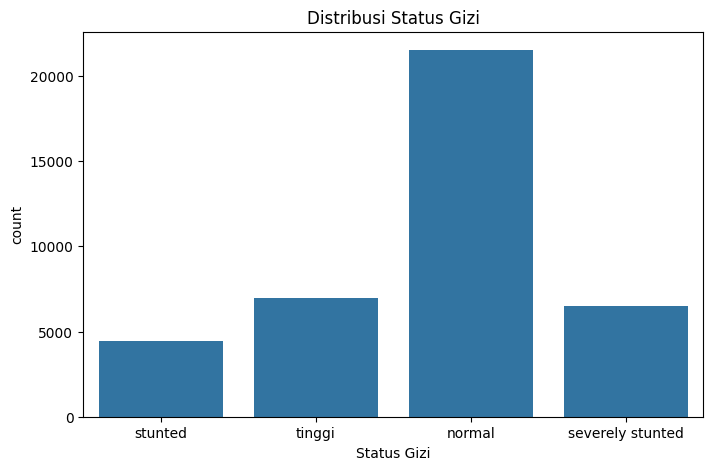

In [35]:
print(df['Status Gizi'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Status Gizi')
plt.title('Distribusi Status Gizi')
plt.show()

# Berdasarkan grafik dan hitungan, sebagian besar balita memiliki Status Gizi 'normal',
# diikuti oleh 'tinggi', 'severely stunted', dan yang paling sedikit adalah 'stunted'.

# b. Menampilkan Distribusi Jenis Kelamin

Jenis Kelamin
perempuan    20024
laki-laki    19401
Name: count, dtype: int64


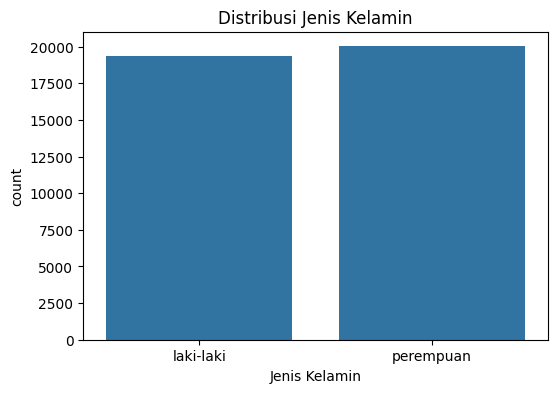

In [36]:
print(df['Jenis Kelamin'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Jenis Kelamin')
plt.title('Distribusi Jenis Kelamin')
plt.show()

# Berdasarkan grafik dan hitungan, jumlah balita perempuan sedikit lebih banyak
#dibandingkan balita laki-laki.

# c. Distribusi Umur Balita

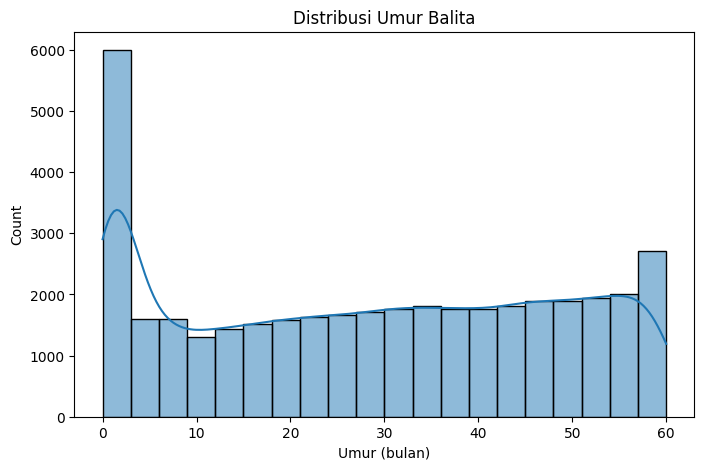

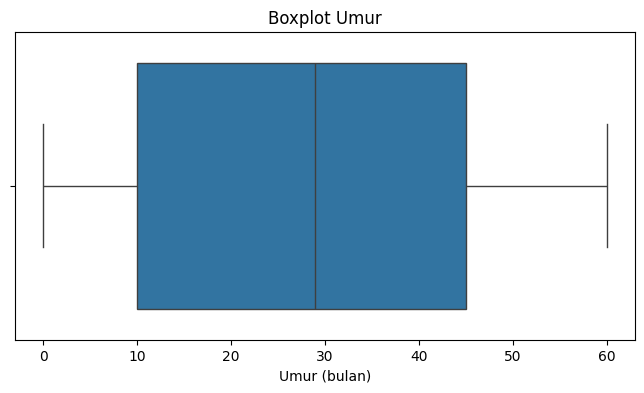

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(df['Umur (bulan)'], bins=20, kde=True)
plt.title('Distribusi Umur Balita')
plt.show()
# Histogram menunjukkan distribusi umur balita cenderung memiliki dua puncak,
# yaitu pada usia sangat muda (sekitar 0-5 bulan) dan pada usia yang lebih tua (sekitar 55-60 bulan), dengan distribusi yang lebih merata di antara usia tersebut.

plt.figure(figsize=(8,4))
sns.boxplot(x=df['Umur (bulan)'])
plt.title('Boxplot Umur')
plt.show()
# Boxplot menunjukkan bahwa sebagian besar umur balita berada di kisaran 15 hingga 45 bulan,
# dengan median sekitar 30 bulan. Tidak ada outlier yang signifikan terlihat.

# d. Distribusi Tinggi Badan

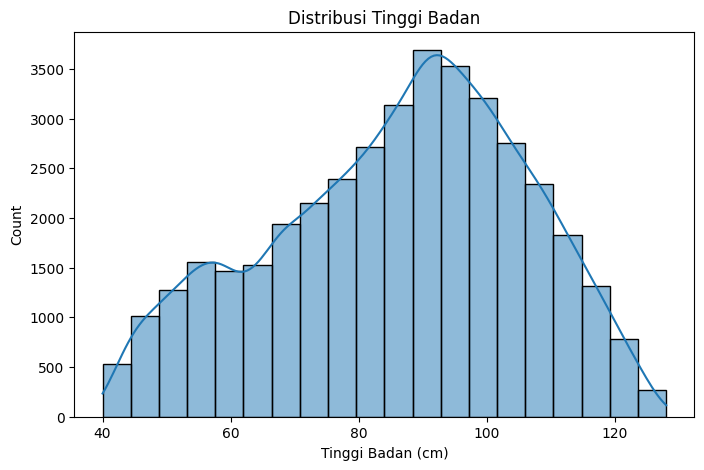

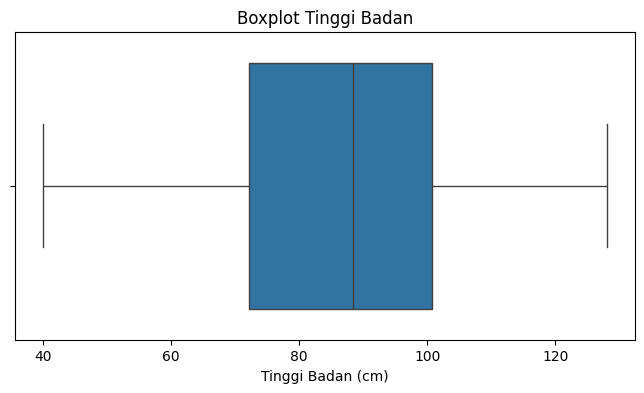

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tinggi Badan (cm)'], bins=20, kde=True)
plt.title('Distribusi Tinggi Badan')
plt.show()
# Histogram menunjukkan bahwa distribusi tinggi badan balita cenderung normal (berbentuk lonceng)
# dengan puncak terbanyak berada di sekitar 90-100 cm.

plt.figure(figsize=(8,4))
sns.boxplot(x=df['Tinggi Badan (cm)'])
plt.title('Boxplot Tinggi Badan')
plt.show()
# Boxplot mengindikasikan bahwa sebagian besar tinggi badan balita berkisar antara 75 cm hingga 100 cm,
# dengan median sekitar 90 cm. Ada beberapa nilai yang lebih rendah dari 75 cm dan lebih tinggi dari 100 cm, tetapi tidak ada outlier ekstrem yang mencolok.

# e. Perbandingan Tinggi Badan Berdasarkan Status Gizi

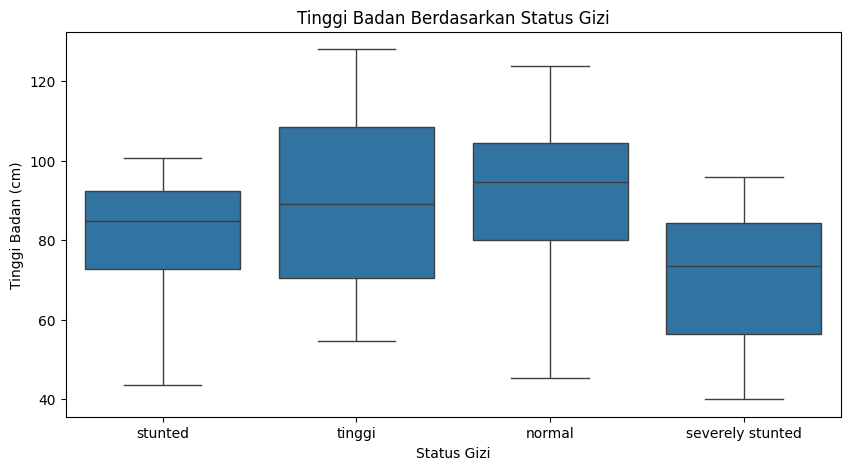

In [41]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Status Gizi', y='Tinggi Badan (cm)')
plt.title('Tinggi Badan Berdasarkan Status Gizi')
plt.show()
# Boxplot menunjukkan perbedaan tinggi badan yang jelas antara status gizi.
# Balita dengan status gizi 'tinggi' memiliki tinggi badan tertinggi, diikuti 'normal', 'stunted', dan 'severely stunted' memiliki tinggi badan terendah. Terdapat beberapa outlier pada setiap kategori, terutama pada 'stunted' dan 'severely stunted' yang menunjukkan tinggi badan yang lebih rendah.

# f. Perbandingan Umur Berdasarkan Status Gizi

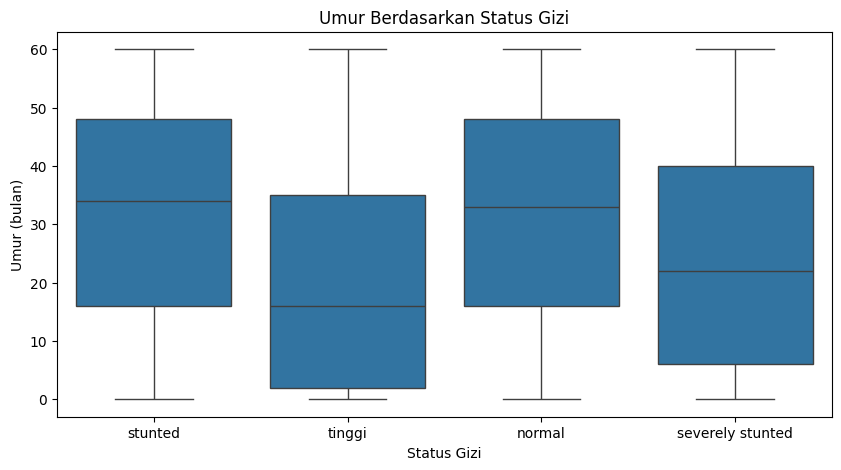

In [42]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Status Gizi', y='Umur (bulan)')
plt.title('Umur Berdasarkan Status Gizi')
plt.show()
# Boxplot ini menunjukkan bahwa balita dengan status gizi 'tinggi' cenderung memiliki umur yang lebih muda dengan rentang umur yang sempit.
# Sementara itu, status 'stunted' dan 'normal' menunjukkan distribusi umur yang lebih lebar, mencapai usia balita yang lebih tua. Balita 'severely stunted' memiliki rentang umur yang juga relatif muda, mirip dengan status 'tinggi'.

# g. Hubungan Umur dan Tinggi Badan

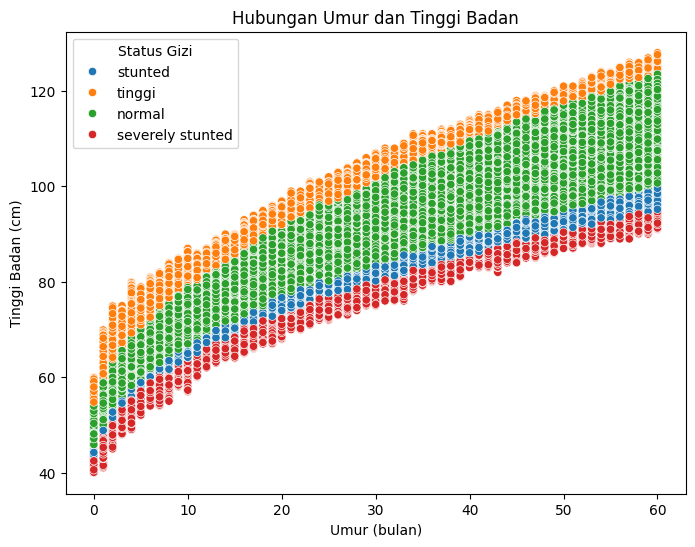

In [43]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='Umur (bulan)',
    y='Tinggi Badan (cm)',
    hue='Status Gizi'
)
plt.title('Hubungan Umur dan Tinggi Badan')
plt.show()
# Grafik ini menunjukkan hubungan positif antara umur dan tinggi badan, di mana tinggi badan cenderung meningkat seiring bertambahnya umur.
# Status gizi yang berbeda membentuk pita-pita yang jelas: balita 'severely stunted' dan 'stunted' berada di pita tinggi badan yang lebih rendah untuk setiap kelompok umur,
# sedangkan 'normal' dan 'tinggi' berada di pita yang lebih atas secara berurutan. Ini menunjukkan bahwa tinggi badan balita sangat berkorelasi dengan status gizinya.

# h. Rata-rata Tinggi Badan Setiap Status Gizi

In [44]:
df.groupby('Status Gizi')['Tinggi Badan (cm)'].mean()
# Hasil ini menunjukkan rata-rata tinggi badan balita untuk setiap kategori status gizi. Terlihat bahwa balita dengan status gizi 'normal' memiliki rata-rata tinggi badan tertinggi (sekitar 90.7 cm)
# diikuti oleh 'tinggi' (sekitar 89.8 cm). Sementara itu, balita 'stunted' (sekitar 80.5 cm) dan 'severely stunted' (sekitar 70.4 cm) memiliki rata-rata tinggi badan yang lebih rendah secara signifikan.

,Tinggi Badan (cm)
Status Gizi,
normal,90.715273
severely stunted,70.362530
stunted,80.488385
tinggi,89.791740


# i. Rata-rata Umur Setiap Status Gizi

In [45]:
print(df.groupby('Status Gizi')['Umur (bulan)'].mean())
# Hasil ini menunjukkan rata-rata umur balita untuk setiap kategori status gizi. Balita dengan status gizi 'stunted' dan 'normal' memiliki rata-rata umur yang lebih tinggi (sekitar 31 bulan),
# sedangkan 'severely stunted' (sekitar 24 bulan) dan 'tinggi' (sekitar 20 bulan) memiliki rata-rata umur yang lebih muda. Ini mengindikasikan bahwa masalah stunting bisa terjadi pada rentang umur yang lebih luas, termasuk usia balita yang lebih tua.

Status Gizi
normal              31.456912
severely stunted    24.161503
stunted             31.635952
tinggi              20.325065
Name: Umur (bulan), dtype: float64


# j. Crosstab Jenis Kelamin dan Status Gizi

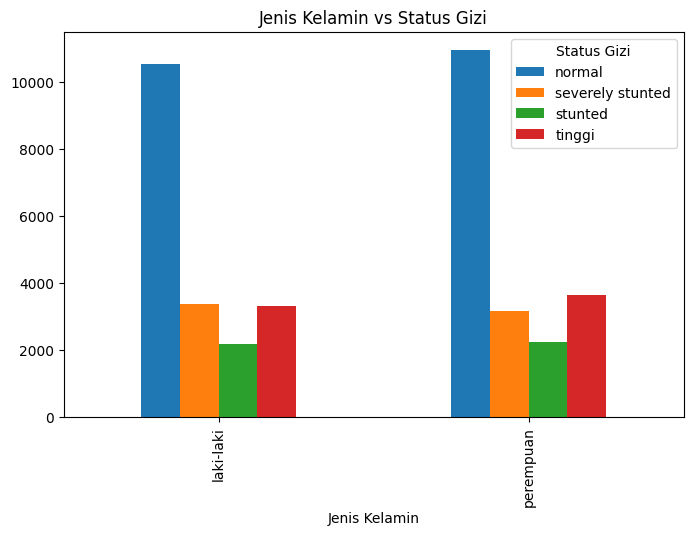

In [46]:
pd.crosstab(df['Jenis Kelamin'], df['Status Gizi'])

pd.crosstab(
    df['Jenis Kelamin'],
    df['Status Gizi']
).plot(kind='bar', figsize=(8,5))

plt.title('Jenis Kelamin vs Status Gizi')
plt.show()
# Grafik ini menunjukkan distribusi status gizi antara laki-laki dan perempuan. Terlihat bahwa status gizi 'normal' mendominasi pada kedua jenis kelamin.
# Pola distribusi status gizi (normal, tinggi, severely stunted, stunted) relatif serupa antara balita laki-laki dan perempuan, dengan jumlah balita perempuan sedikit lebih banyak di setiap kategori status gizi dibandingkan laki-laki.

# 5. Seleksi dan Persiapan Fitur

# a. Menentukan Target (Label)

In [49]:
print(df['Status Gizi'].unique())
# Kode ini digunakan untuk menampilkan semua nilai unik yang ada di kolom 'Status Gizi'.
# Tujuannya adalah untuk memahami kategori-kategori status gizi yang ada di dataset sebelum diproses lebih lanjut, misalnya diubah ke format numerik.

['stunted' 'tinggi' 'normal' 'severely stunted']


# b. Menentukan Fitur yang Digunakan

In [50]:
X = df[['Umur (bulan)', 'Jenis Kelamin', 'Tinggi Badan (cm)']]
# Kode ini berfungsi untuk memilih kolom-kolom 'Umur (bulan)', 'Jenis Kelamin', dan 'Tinggi Badan (cm)' dari DataFrame 'df'.
# Kolom-kolom ini akan menjadi fitur (variabel independen) yang akan digunakan untuk melatih model machine learning dalam memprediksi 'Status Gizi'.

# c. Menentukan Variabel Target

In [51]:
y = df['Status Gizi']
# Kode ini berfungsi untuk memilih kolom 'Status Gizi' dari DataFrame 'df' dan menyimpannya sebagai variabel 'y'.
# 'y' akan menjadi variabel target (dependent variable) yang akan diprediksi oleh model machine learning.

# d. Mengubah Jenis Kelamin Menjadi Numerik

In [59]:
le_gender = LabelEncoder()

df['Jenis Kelamin'] = le_gender.fit_transform(df['Jenis Kelamin'])

print(df['Jenis Kelamin'].unique())

# laki-laki = 0
# perempuan = 1

[0 1]


# e. Mengubah Label Status Gizi Menjadi Numerik

In [58]:
print(df['Status Gizi'].unique())

['stunted' 'tinggi' 'normal' 'severely stunted']


In [60]:
le_status = LabelEncoder()

df['Status Gizi'] = le_status.fit_transform(df['Status Gizi'])

print(df['Status Gizi'].unique())

# 0 = normal
# 1 = severely stunted
# 2 = stunted
# 3 = tinggi

[2 3 0 1]


# f. Melihat Mapping Label

In [61]:
for i, label in enumerate(le_status.classes_):
    print(i, "=", label)

0 = normal
1 = severely stunted
2 = stunted
3 = tinggi


# g. Membuat Ulang Fitur dan Target Setelah Encoding

In [62]:
X = df[['Umur (bulan)', 'Jenis Kelamin', 'Tinggi Badan (cm)']]
# Setelah kolom 'Jenis Kelamin' diubah menjadi numerik, kita perlu mendefinisikan ulang variabel fitur (X)
# agar mencakup nilai numerik yang telah di-encode tersebut.

y = df['Status Gizi']
# Demikian pula, setelah kolom 'Status Gizi' diubah menjadi numerik, variabel target (y) juga perlu didefinisikan ulang
# untuk memastikan ia mencerminkan label numerik yang telah di-encode, siap untuk pelatihan model.

# h. Memeriksa Bentuk Data Fitur dan Target

In [63]:
print(X.shape)
print(y.shape)

(120999, 3)
(120999,)


# i. Memeriksa Data Fitur dan Data Terget

In [67]:
print(X.head())
print("----------------------------------------------------")
print(y.head())

   Umur (bulan)  Jenis Kelamin  Tinggi Badan (cm)
0             0              0          44.591973
1             0              0          56.705203
2             0              0          46.863358
3             0              0          47.508026
4             0              0          42.743494
----------------------------------------------------
0    2
1    3
2    0
3    0
4    1
Name: Status Gizi, dtype: int64


# j. Memastikan Tidak Ada Nilai Kosong Lagi

In [68]:
print(X.isnull().sum())
print(y.isnull().sum())

Umur (bulan)         0
Jenis Kelamin        0
Tinggi Badan (cm)    0
dtype: int64
0


## 6. Pembagian Data

# a. Membagi Data Training dan Testing

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# Kode ini berfungsi untuk membagi dataset menjadi dua bagian: data pelatihan (training set)
# dan data pengujian (testing set). Ini sangat penting dalam machine learning untuk menguji
# kinerja model pada data yang belum pernah dilihat sebelumnya.
# - 'X' adalah fitur (variabel independen) dan 'y' adalah target (variabel dependen).
# - 'test_size=0.2' berarti 20% data akan digunakan untuk pengujian dan 80% untuk pelatihan.
# - 'random_state=42' digunakan untuk memastikan pembagian data yang konsisten (reproducible) setiap kali kode dijalankan.
# - 'stratify=y' memastikan bahwa proporsi kelas (Status Gizi) di data pelatihan dan pengujian tetap sama dengan proporsi di dataset asli, mencegah bias pada model.

# b. Melihat Ukuran Data Setelah Dibagi

In [73]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (96799, 3)
X_test  : (24200, 3)
y_train : (96799,)
y_test  : (24200,)


## 7. Pembuatan Model Decision Tree

# a. Konfigurasi Model Decison Tree

In [76]:
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Melihat konfigurasi model
print(dt_model)

# Melihat seluruh parameter
print(dt_model.get_params())

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=5,
                       min_samples_split=10, random_state=42)
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


## 8. Pelatihan Model

# a. Melatih Model dengan Data Training

In [78]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=5,
                       min_samples_split=10, random_state=42)

# b. Menampilkan Informasi Dasar Model

In [79]:
print(dt_model.classes_)

[0 1 2 3]


# c. Melihat Jumlah Fitur yang Digunakan

In [81]:
print(dt_model.n_features_in_)

print(dt_model.feature_names_in_)

3
['Umur (bulan)' 'Jenis Kelamin' 'Tinggi Badan (cm)']


# d. Melihat Hasil Pohon

In [84]:
print("Depth:", dt_model.get_depth())
# Kedalaman pohon keputusan adalah 5, yang sesuai dengan parameter 'max_depth=5' yang kita atur.
# Kedalaman yang tidak terlalu tinggi menunjukkan model yang tidak terlalu kompleks dan cenderung
# mencegah overfitting.

print("Jumlah Node:", dt_model.tree_.node_count)
# Jumlah node (titik keputusan dan daun) dalam pohon adalah 61. Ini adalah jumlah total
# kotak dalam visualisasi pohon. Jumlah ini wajar untuk kedalaman 5.

print("Jumlah Leaf:", dt_model.get_n_leaves())
# Jumlah daun (node akhir yang memberikan prediksi kelas) adalah 31. Ini juga wajar
# untuk pohon dengan kedalaman 5. Secara umum, semakin banyak daun, semakin kompleks modelnya.

Depth: 5
Jumlah Node: 61
Jumlah Leaf: 31


## 9. Prediksi

# a. Melakukan Prediksi pada Data Testing

In [86]:
y_pred = dt_model.predict(X_test)

print(y_pred[:10])

[2 3 1 3 1 0 1 0 0 0]


# b. Membandingkan Data Aktual dan Prediksi

In [87]:
hasil_prediksi = pd.DataFrame({
    'Aktual': y_test,
    'Prediksi': y_pred
})

print(hasil_prediksi.head(10))

        Aktual  Prediksi
102675       1         2
42197        3         3
30511        1         1
82885        0         3
12813        1         1
29274        1         0
71088        2         1
57919        0         0
49360        0         0
91081        0         0


# c. Melihat Prediksi yang Benar

In [88]:
hasil_prediksi[hasil_prediksi['Aktual'] == hasil_prediksi['Prediksi']]

,Aktual,Prediksi
42197,3,3
30511,1,1
12813,1,1
57919,0,0
49360,0,0
...,...,...
118672,3,3
73206,0,0
102961,1,1
22556,0,0


# d. Melihat Prediksi yang Salah

In [89]:
hasil_prediksi[hasil_prediksi['Aktual'] != hasil_prediksi['Prediksi']]

,Aktual,Prediksi
102675,1,2
82885,0,3
29274,1,0
71088,2,1
30003,3,0
...,...,...
66491,2,0
9419,3,0
71724,2,1
1412,0,1


# e. Prediksi Satu Data Baru

In [90]:
data_baru = [[24, 0, 82]]

prediksi = dt_model.predict(data_baru)

print(prediksi)

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# f. Mengubah Hasil Prediksi ke Label Asli

In [91]:
label_prediksi = le_status.inverse_transform(prediksi)

print(label_prediksi)

['normal']


# g. Prediksi Beberapa Data Sekaligus

In [97]:
data_baru = [
    [24, 0, 60],   # sangat pendek
    [24, 0, 70],   # agak pendek
    [24, 0, 82],   # normal
    [24, 0, 100]   # sangat tinggi
]

prediksi = dt_model.predict(data_baru)

['severely stunted' 'severely stunted' 'normal' 'tinggi']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [98]:
print(le_status.inverse_transform(prediksi))

['severely stunted' 'severely stunted' 'normal' 'tinggi']


## 10. Evaluasi Model

# a. Menghitung Accuracy (Akurasi)

In [100]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 70.14%


# b. Membuat Confusion Matrix

[[11427   796   897   431]
 [  582  2807   585     0]
 [  852   805  1106     0]
 [ 2141   136     0  1635]]


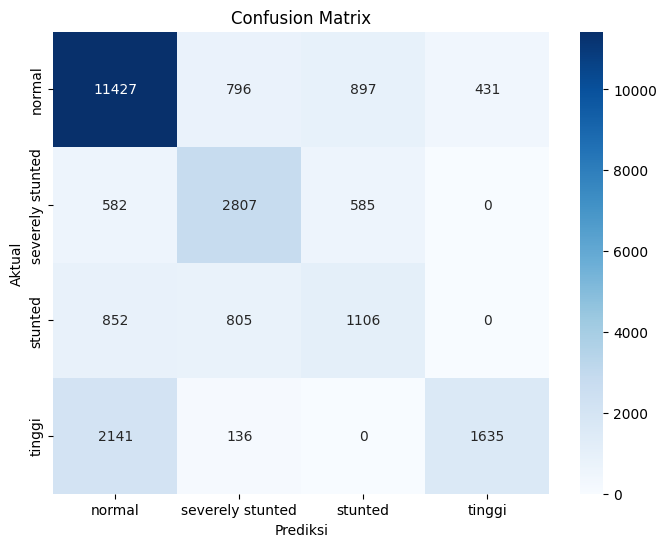

In [104]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_status.classes_,
    yticklabels=le_status.classes_
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

# d. Membuat Classification Report

In [105]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=le_status.classes_
    )
)

                  precision    recall  f1-score   support

          normal       0.76      0.84      0.80     13551
severely stunted       0.62      0.71      0.66      3974
         stunted       0.43      0.40      0.41      2763
          tinggi       0.79      0.42      0.55      3912

        accuracy                           0.70     24200
       macro avg       0.65      0.59      0.60     24200
    weighted avg       0.70      0.70      0.69     24200



## 11. Analisis Feature Importance

# a. Menampilkan Nilai Feature Importance

In [112]:
for fitur, importance in zip(X.columns, dt_model.feature_importances_):
    print(f"{fitur}: {importance:.4f}")
print ("------------------------")
for fitur, importance in zip(X.columns, dt_model.feature_importances_):
    print(
        f"{fitur}: {importance*100:.2f}%"
    )

Umur (bulan): 0.3676
Jenis Kelamin: 0.0000
Tinggi Badan (cm): 0.6324
------------------------
Umur (bulan): 36.76%
Jenis Kelamin: 0.00%
Tinggi Badan (cm): 63.24%


# b. Grafik Feature Importance

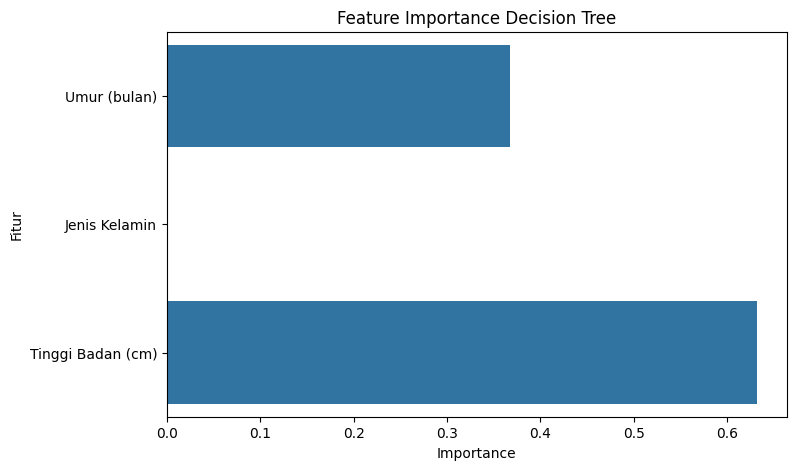

In [109]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Fitur'
)

plt.title('Feature Importance Decision Tree')
plt.show()

## 12. Tuning Model

# a. Menyimpan Akurasi Model Awal

In [113]:
print("Accuracy Awal:", accuracy_score(y_test, y_pred))

Accuracy Awal: 0.7014462809917356


# b. Mencoba Beberapa Nilai max_depth

In [114]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

for depth in [3, 5, 7, 10, 15]:

    model = DecisionTreeClassifier(
        criterion='entropy',
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    prediksi = model.predict(X_test)

    akurasi = accuracy_score(y_test, prediksi)

    print(f"max_depth={depth} -> Accuracy={akurasi:.4f}")

max_depth=3 -> Accuracy=0.6031
max_depth=5 -> Accuracy=0.7014
max_depth=7 -> Accuracy=0.8303
max_depth=10 -> Accuracy=0.9431
max_depth=15 -> Accuracy=0.9989


# c. Mencoba dengan depth=6 agar tidak terlalu rumit

In [122]:
best_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=6,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

In [123]:
best_model.fit(X_train, y_train)

best_pred = best_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, best_pred))

Accuracy: 0.7816115702479339


## 13. Visualisasi Decision Tree

# a. Menampilkan Pohon Keputusan

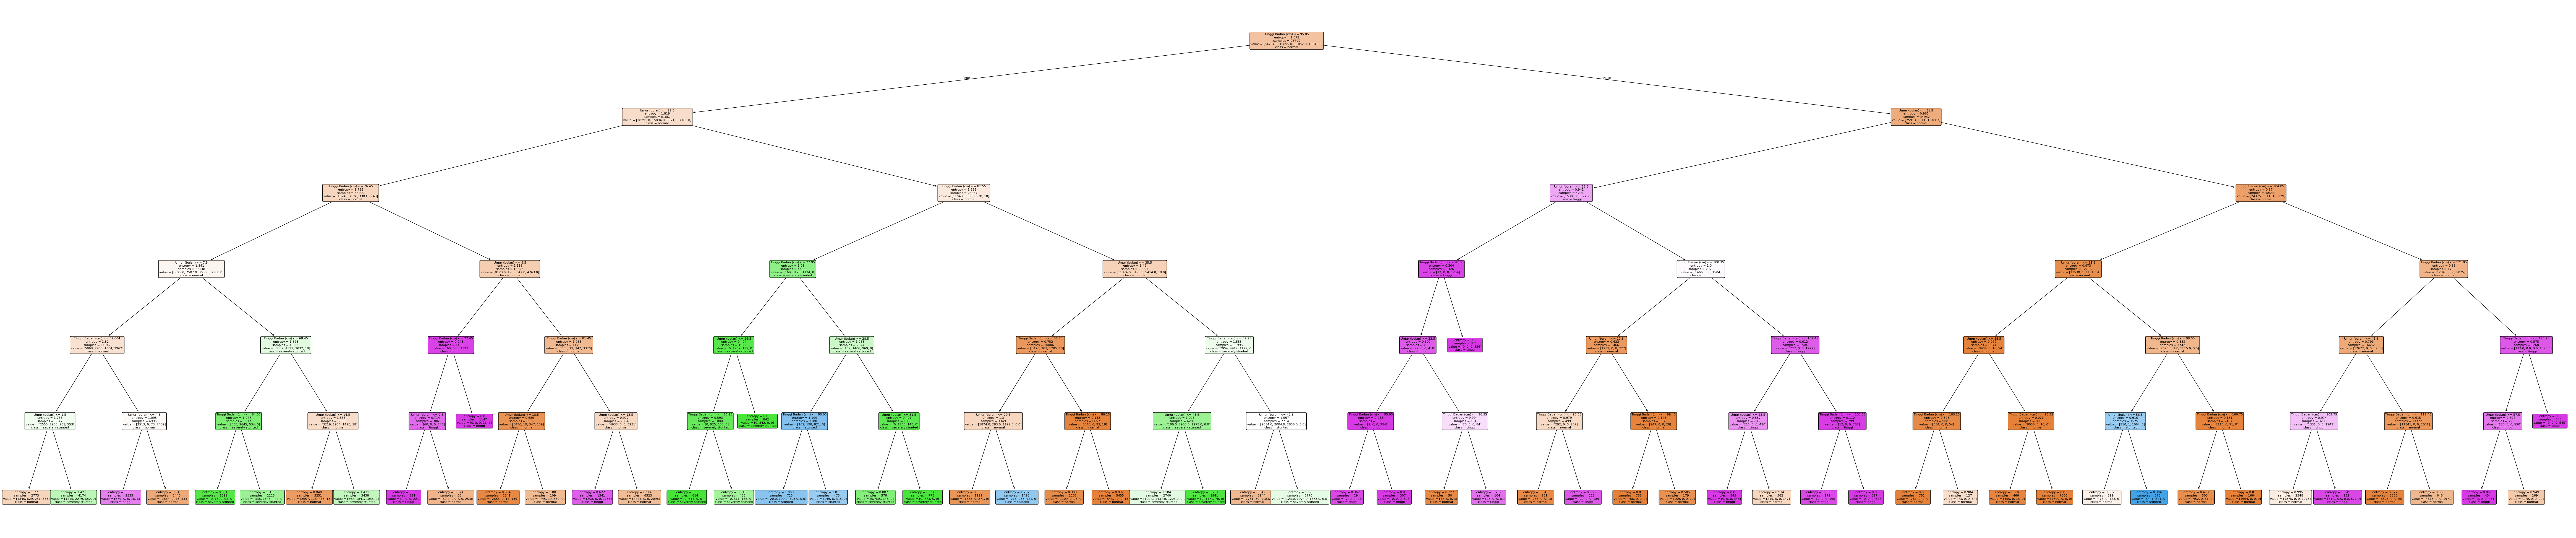

In [129]:
plt.figure(figsize=(120, 25))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=le_status.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

# b. Menampilkan Informasi Pohon

In [130]:
print("Depth:", best_model.get_depth())
print("Jumlah Node:", best_model.tree_.node_count)
print("Jumlah Leaf:", best_model.get_n_leaves())

Depth: 6
Jumlah Node: 115
Jumlah Leaf: 58


## 14. Pengujian Data Baru

# a. Mencoba dengan beberapa data baru

In [131]:
data_uji = pd.DataFrame({
    'Umur (bulan)': [12, 24, 48],
    'Jenis Kelamin': [0, 1, 0],
    'Tinggi Badan (cm)': [65, 82, 110]
})

prediksi = best_model.predict(data_uji)

data_uji['Prediksi Status Gizi'] = le_status.inverse_transform(prediksi)

print(data_uji)

   Umur (bulan)  Jenis Kelamin  Tinggi Badan (cm) Prediksi Status Gizi
0            12              0                 65     severely stunted
1            24              1                 82               normal
2            48              0                110               normal


In [132]:
def prediksi_gizi(umur, jenis_kelamin, tinggi):

    data = [[umur, jenis_kelamin, tinggi]]

    hasil = best_model.predict(data)

    status = le_status.inverse_transform(hasil)

    return status[0]

In [146]:
print(prediksi_gizi(0, 0, 78))

tinggi


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## 15. Kesimpulan

> Berdasarkan hasil pelatihan dan pengujian model Machine Learning menggunakan algoritma Decision Tree, diperoleh model yang mampu mengklasifikasikan status gizi balita berdasarkan indikator Tinggi Badan menurut Umur (TB/U) ke dalam kategori *severely stunted*, *stunted*, *normal*, dan *tinggi*. Proses evaluasi menunjukkan bahwa model awal menghasilkan akurasi sebesar 70,14%. Selanjutnya dilakukan proses tuning parameter untuk memperoleh performa yang lebih optimal.
>
> Hasil tuning menunjukkan bahwa model terbaik diperoleh dengan parameter **criterion = entropy**, **max_depth = 6**, **min_samples_split = 2**, dan **min_samples_leaf = 1**. Pemilihan **max_depth = 6** dilakukan karena mampu menghasilkan performa yang sangat baik sekaligus menjaga struktur pohon tetap mudah diinterpretasikan dibandingkan pohon yang terlalu dalam.
>
> Berdasarkan analisis *feature importance*, diketahui bahwa fitur **Tinggi Badan (cm)** memiliki pengaruh terbesar dalam proses klasifikasi dengan nilai importance sebesar **63,24%**, diikuti oleh **Umur (bulan)** sebesar **36,76%**, sedangkan **Jenis Kelamin** tidak memberikan kontribusi yang signifikan terhadap keputusan model. Hal ini menunjukkan bahwa klasifikasi status gizi TB/U lebih banyak dipengaruhi oleh hubungan antara tinggi badan dan umur balita.
>
> Dengan model terbaik yang memiliki **kedalaman pohon (max_depth) sebesar 6**, sistem dapat digunakan sebagai alat bantu dalam proses skrining status gizi balita di Posyandu. Model mampu memberikan prediksi status gizi berdasarkan data hasil pengukuran balita sehingga dapat membantu petugas kesehatan dalam melakukan identifikasi awal terhadap balita yang berisiko mengalami masalah pertumbuhan.
